In [27]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
import inrix_data_science_utils.api.sql_server as sql
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import pyodbc   
import altair as alt
import datetime

## Load in Data (CHANGE FILE NAMES & CITY NAMES)

In [30]:
city_name = "Frederick"         ## e.g. "New York"
city_lower = "frederick"        ## e.g. "new_york"
city_short = "frederick"              ## e.g. "ny"

city_data_1 = pd.read_csv('ra_data/frederick_md/frederick_2023-04-01_to_2023-07-31_60_min/data.csv')
city_data_2 = pd.read_csv('ra_data/frederick_md/frederick_2023-08-01_to_2023-11-30_60_min/data.csv')
city_frames = [city_data_1, city_data_2]
city_data = pd.concat(city_frames)
city_data_1 = ""
city_data_2 = ""

city_data = city_data.drop(columns = ['Travel Time(Minutes)', 'CValue', 'Pct Score30', 'Pct Score20', 'Pct Score10', 
                                        'Road Closure', 'Corridor/Region Name'])

city_data['Date Time'] = pd.to_datetime(city_data['Date Time'])
city_data['UTC Date Time'] = pd.to_datetime(city_data['UTC Date Time'])
city_data

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour)
0,2023-04-01 00:00:00+00:00,449089465,2023-04-01 00:00:00+00:00,55.0,56.0,58
1,2023-04-01 01:00:00+00:00,449089465,2023-04-01 01:00:00+00:00,58.0,53.0,58
2,2023-04-01 02:00:00+00:00,449089465,2023-04-01 02:00:00+00:00,62.0,58.0,58
3,2023-04-01 03:00:00+00:00,449089465,2023-04-01 03:00:00+00:00,64.0,63.0,58
4,2023-04-01 04:00:00+00:00,449089465,2023-04-01 04:00:00+00:00,51.0,63.0,58
...,...,...,...,...,...,...
12578683,2023-09-25 19:00:00+00:00,1310561705,2023-09-25 19:00:00+00:00,81.0,74.0,76
12578684,2023-09-25 20:00:00+00:00,1310561705,2023-09-25 20:00:00+00:00,77.0,76.0,76
12578685,2023-09-25 21:00:00+00:00,1310561705,2023-09-25 21:00:00+00:00,80.0,76.0,76
12578686,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76


In [31]:
xd_seg_list = list(set(city_data['Segment ID'].to_list()))

xd_seg_tuple = tuple(list(set(city_data['Segment ID'].to_list())))

len(xd_seg_tuple)

4296

In [10]:
#### Seattle is 74,000 segments. 24,000 worked for New York, so will need to split the list and loop for chunks of 10-15,000
def chunker(seq, size):
    return (seq[pos:pos + size] for pos in range(0, len(seq), size))

i = 0
for xd_seg_tuple_chunk in chunker(xd_seg_tuple, 20000):
    
    Driver = '{ODBC Driver 18 for SQL Server}'
    Server = '10.105.204.215'
    Database = 'master'
    Username = 'DSDBUser'
    Password = 'Science99!'
    
    cnxn = pyodbc.connect(DRIVER = Driver, SERVER = Server, DATABASE = Database,
                          UID = Username, PWD = Password, TrustServerCertificate='yes')
    cursor = cnxn.cursor()
    query_1 = f"""SELECT  C.CSegID \
                   ,R.LRSID \
            	   ,L.Name \
                   ,ExternalSegID as 'XDSegmemtId' \
                   ,LengthMeters \
                   ,FRC \
                   ,RoadName \
              FROM ReportSegment2401.dbo.Rseg R \
              JOIN ReportSegment2401.dbo.RSegCSeg C on R.RsegId = C.RSegID \
              JOIN ReportSegment2401.dbo.LRS L on R.LRSID = L.LRSID \
              WHERE L.RSegTypeID=4 \
              AND R.ExternalSegID in {xd_seg_tuple_chunk}"""

    xd_to_cseg_iter = pd.read_sql(query_1, cnxn)

    if i == 0 :
        xd_to_cseg = xd_to_cseg_iter
    else : 
        xd_to_cseg = pd.concat([xd_to_cseg, xd_to_cseg_iter])

    i = i + 1
        
xd_to_cseg.to_csv('xd_to_cseg_' + city_short + '.csv', index=False)
xd_to_cseg

/var/folders/zb/1v6634gn2vbdc25htcjj6xc40000gn/T/ipykernel_51378/212628505.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  xd_to_cseg_iter = pd.read_sql(query_1, cnxn)


,CSegID,LRSID,Name,XDSegmemtId,LengthMeters,FRC,RoadName
0,624807226,2558,2024.01 USA XD INRIX,1310225721,220.744934,2,US-15
1,564313,2558,2024.01 USA XD INRIX,1310423642,182.647247,4,None
2,564270,2558,2024.01 USA XD INRIX,1310280977,58.795971,4,Antietam Campaign Bywy|Historic National Rd|MD...
3,1019891414,2558,2024.01 USA XD INRIX,1310361498,40.302876,4,None
4,1019892037,2558,2024.01 USA XD INRIX,429096821,223.547134,4,Antietam Campaign Bywy|Historic National Rd|Ol...
...,...,...,...,...,...,...,...
5262,624785347,2558,2024.01 USA XD INRIX,484696453,688.311523,5,Old Swimming Pool Rd
5263,624785350,2558,2024.01 USA XD INRIX,484768041,688.311523,5,Old Swimming Pool Rd
5264,624814634,2558,2024.01 USA XD INRIX,484694983,421.059326,5,W Baldwin Rd
5265,250855481,2558,2024.01 USA XD INRIX,484721651,288.957825,5,New Design Rd


In [32]:
xd_to_cseg = pd.read_csv('xd_to_cseg_' + city_short + '.csv')

city_data_merge = pd.merge(city_data, xd_to_cseg[['XDSegmemtId', 'FRC']], how = 'left', 
                            left_on = ['Segment ID'], right_on = ['XDSegmemtId'])

city_data_merge = city_data_merge.drop(columns = ['XDSegmemtId'])
city_data_merge

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour),FRC
0,2023-04-01 00:00:00+00:00,449089465,2023-04-01 00:00:00+00:00,55.0,56.0,58,4
1,2023-04-01 01:00:00+00:00,449089465,2023-04-01 01:00:00+00:00,58.0,53.0,58,4
2,2023-04-01 02:00:00+00:00,449089465,2023-04-01 02:00:00+00:00,62.0,58.0,58,4
3,2023-04-01 03:00:00+00:00,449089465,2023-04-01 03:00:00+00:00,64.0,63.0,58,4
4,2023-04-01 04:00:00+00:00,449089465,2023-04-01 04:00:00+00:00,51.0,63.0,58,4
...,...,...,...,...,...,...,...
30843547,2023-09-25 21:00:00+00:00,1310561705,2023-09-25 21:00:00+00:00,80.0,76.0,76,3
30843548,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76,3
30843549,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76,3
30843550,2023-09-25 23:00:00+00:00,1310561705,2023-09-25 23:00:00+00:00,78.0,79.0,76,3


### Add Features

In [33]:
# Other features
city_data_features = city_data_merge

city_data_features['dow'] = city_data_features['Date Time'].dt.strftime('%w').astype(float)
city_data_features['wd_or_we'] = city_data_features.apply(lambda row: 0 if (row['dow'] <=4) else 1 , axis = 1)
city_data_features['hod'] = city_data_features['Date Time'].dt.strftime('%H').astype(float)
city_data_features['congestion'] = city_data_features['Speed(km/hour)'] - city_data_features['Ref Speed(km/hour)']
city_data_features['congestion_pc'] = city_data_features['congestion'] / city_data_features['Ref Speed(km/hour)'] * 100

In [34]:
city_data_features

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour),FRC,dow,wd_or_we,hod,congestion,congestion_pc
0,2023-04-01 00:00:00+00:00,449089465,2023-04-01 00:00:00+00:00,55.0,56.0,58,4,6.0,1,0.0,-3.0,-5.172414
1,2023-04-01 01:00:00+00:00,449089465,2023-04-01 01:00:00+00:00,58.0,53.0,58,4,6.0,1,1.0,0.0,0.000000
2,2023-04-01 02:00:00+00:00,449089465,2023-04-01 02:00:00+00:00,62.0,58.0,58,4,6.0,1,2.0,4.0,6.896552
3,2023-04-01 03:00:00+00:00,449089465,2023-04-01 03:00:00+00:00,64.0,63.0,58,4,6.0,1,3.0,6.0,10.344828
4,2023-04-01 04:00:00+00:00,449089465,2023-04-01 04:00:00+00:00,51.0,63.0,58,4,6.0,1,4.0,-7.0,-12.068966
...,...,...,...,...,...,...,...,...,...,...,...,...
30843547,2023-09-25 21:00:00+00:00,1310561705,2023-09-25 21:00:00+00:00,80.0,76.0,76,3,1.0,0,21.0,4.0,5.263158
30843548,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76,3,1.0,0,22.0,-5.0,-6.578947
30843549,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76,3,1.0,0,22.0,-5.0,-6.578947
30843550,2023-09-25 23:00:00+00:00,1310561705,2023-09-25 23:00:00+00:00,78.0,79.0,76,3,1.0,0,23.0,2.0,2.631579


In [35]:
bin_width = 5
bin_max = np.ceil(city_data_features['Speed(km/hour)'].max()/bin_width) * bin_width
speed_bins = np.arange(0, bin_max, bin_width)
city_data_features['speed_bin'] = np.digitize(city_data_features['Speed(km/hour)'].values, speed_bins)

bin_max_ref = np.ceil(city_data_features['Ref Speed(km/hour)'].max()/bin_width) * bin_width
speed_bins_ref = np.arange(0, bin_max_ref, bin_width)
city_data_features['speed_bin_ref'] = np.digitize(city_data_features['Ref Speed(km/hour)'].values, speed_bins_ref)

city_data_features

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour),FRC,dow,wd_or_we,hod,congestion,congestion_pc,speed_bin,speed_bin_ref
0,2023-04-01 00:00:00+00:00,449089465,2023-04-01 00:00:00+00:00,55.0,56.0,58,4,6.0,1,0.0,-3.0,-5.172414,12,12
1,2023-04-01 01:00:00+00:00,449089465,2023-04-01 01:00:00+00:00,58.0,53.0,58,4,6.0,1,1.0,0.0,0.000000,12,12
2,2023-04-01 02:00:00+00:00,449089465,2023-04-01 02:00:00+00:00,62.0,58.0,58,4,6.0,1,2.0,4.0,6.896552,13,12
3,2023-04-01 03:00:00+00:00,449089465,2023-04-01 03:00:00+00:00,64.0,63.0,58,4,6.0,1,3.0,6.0,10.344828,13,12
4,2023-04-01 04:00:00+00:00,449089465,2023-04-01 04:00:00+00:00,51.0,63.0,58,4,6.0,1,4.0,-7.0,-12.068966,11,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30843547,2023-09-25 21:00:00+00:00,1310561705,2023-09-25 21:00:00+00:00,80.0,76.0,76,3,1.0,0,21.0,4.0,5.263158,17,16
30843548,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76,3,1.0,0,22.0,-5.0,-6.578947,15,16
30843549,2023-09-25 22:00:00+00:00,1310561705,2023-09-25 22:00:00+00:00,71.0,76.0,76,3,1.0,0,22.0,-5.0,-6.578947,15,16
30843550,2023-09-25 23:00:00+00:00,1310561705,2023-09-25 23:00:00+00:00,78.0,79.0,76,3,1.0,0,23.0,2.0,2.631579,16,16


In [36]:
import ppscore as pps
 
def run_pps(x:pd.DataFrame, 
            features:list, 
            dependent:str, 
            group:str = None) -> pd.DataFrame:
    '''
    Run PPScore on a dataset
    '''
 
    # Create a copy
    tmp = x.copy()
    
    # No group, create a dummy
    if group is None:
        use_grp = '_'
        tmp[use_grp] = 1
    else:
        use_grp = group
        
    # Run the process
    preds = []
    for a in np.unique(tmp[use_grp].values):
        preds.append(pps.predictors(tmp.loc[tmp[use_grp] == a, 
                                            features + [dependent]], 
                                    y = dependent))
        preds[-1][use_grp] = a
        preds.append(pps.predictors(tmp.loc[tmp[use_grp] == a, 
                                    features + [dependent]], 
                            y = dependent))
        preds[-1][use_grp] = a
        
    # Combine
    preds = pd.concat(preds, ignore_index = True)
    
    # Drop dummy
    if group is None:
        preds = preds.drop(use_grp, axis = 1)
        
    # Return
    return preds
 
def plot_pps(preds:pd.DataFrame, 
             group:str = None):
    '''
    Generate a pyplot of the data
    '''
 
    fig, ax = plt.subplots()
 
    x_map = dict([(v, i) for i, v in enumerate(preds['x'].drop_duplicates().values)])
 
    if group is None:
        use_grp = '_'
        preds[use_grp] = 1
        title = 'Predictive Score by Feature'
    else:
        use_grp = group
        title = f'Predictive Score by Feature and {group}'
    grps = np.unique(preds[use_grp].values)
    width = 1/grps.shape[0]
 
    for i, a in enumerate(grps):
 
        ax.bar(preds.loc[preds[use_grp] == a, 'x'].map(x_map) + (i * width), 
               preds.loc[preds[use_grp] == a, 'ppscore'], 
               width = width,
               label = a)
    ax.set_title(title)
    ax.tick_params(axis = 'x', labelrotation = 90)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Score')
    ax.set_xticks(list(x_map.values()), list(x_map.keys()))
 
    if group is None:
        preds = preds.drop(use_grp, axis = 1)
    else:
        ax.legend()
    return plt

In [37]:
city_data_features.head(1)

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour),FRC,dow,wd_or_we,hod,congestion,congestion_pc,speed_bin,speed_bin_ref
0,2023-04-01 00:00:00+00:00,449089465,2023-04-01 00:00:00+00:00,55.0,56.0,58,4,6.0,1,0.0,-3.0,-5.172414,12,12


In [38]:
features = ['Speed(km/hour)', 'Hist Av Speed(km/hour)', 'Ref Speed(km/hour)', 'FRC', 'dow', 'wd_or_we', 'hod', 'congestion', 
            'speed_bin', 'speed_bin_ref', 'congestion_pc']

pps_mat = pps.matrix(city_data_features[features])

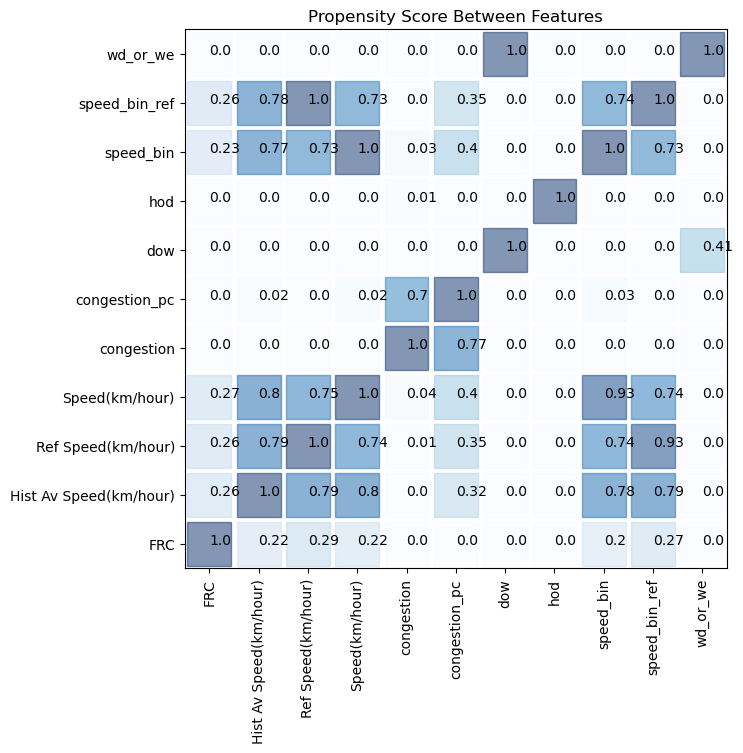

In [39]:
pps_mat = pps_mat.sort_values(['x', 'y'])

fig, ax = plt.subplots(1, 1, figsize = (7, 7))
ax.scatter(pps_mat['x'].values, 
           pps_mat['y'].values, 
           c = pps_mat['ppscore'].values, 
           s = 1000, 
           cmap = 'Blues', 
           alpha = 0.5, 
           marker = 's')

idx = pps_mat['x'].isin(['delta', 'delta_pc']) |\
      pps_mat['y'].isin(['delta', 'delta_pc'])
ax.scatter(pps_mat.loc[idx, 'x'], 
           pps_mat.loc[idx, 'y'], 
           s = 1000, 
           marker = 's', 
           edgecolors = 'green', 
           color = 'none', 
           linewidth = 2)

for row in pps_mat.itertuples():
    ax.text(row.x, 
            row.y, 
            np.round(row.ppscore, 2))
ax.set_title('Propensity Score Between Features')
ax.tick_params(axis='x', labelrotation = 90)
plt.show()

In [40]:
city_data_features = ""

## Averaging by Segment, WeekDay and Hour

In [52]:
print("Started")
print(datetime.datetime.now())

city_data_day = city_data_merge
city_data_merge = ""

print("Table Set Up")
print(datetime.datetime.now())

### Split out the data by week day and hour
city_data_day['dow'] = city_data_day['Date Time'].dt.strftime('%w').astype(float)
# city_data_day['wd_or_we'] = city_data_day.apply(lambda row: 0 if (row['dow'] <=4) else 1 , axis = 1)
city_data_day['hod'] = city_data_day['Date Time'].dt.strftime('%H').astype(float)
# city_data_day = city_data_day[city_data_day['dow'] <= 4]

print("Weekends Not Filtered Out")
print(datetime.datetime.now())

### Split out the pre and post data, average the daily speeds and then re-merge data 
city_data_pre = city_data_day[(city_data_day['Date Time'] >= "2023-05-02") & (city_data_day['Date Time'] < "2023-06-02")]

city_data_pre = city_data_pre.groupby(['dow', 'hod', 'Segment ID']).agg(avg_speed_pre = ('Speed(km/hour)', 'mean'),
                                                                           hist_speed = ('Hist Av Speed(km/hour)', 'mean'),
                                                                           ref_speed = ('Ref Speed(km/hour)', 'mean'),
                                                                           ).reset_index()
print("2023 Pre Data Grouped")
print(datetime.datetime.now())

city_data_post = city_data_day[(city_data_day['Date Time'] >= "2023-06-02") & (city_data_day['Date Time'] < "2023-07-02")]

city_data_post = city_data_post.groupby(['dow', 'hod', 'Segment ID']).agg(avg_speed_post = ('Speed(km/hour)', 'mean'),
                                                                           ).reset_index()

city_data_av_merge = pd.merge(city_data_pre, city_data_post, how = 'left', on = ['dow', 'hod', 'Segment ID'])
city_data_day = ""
city_data_pre = ""
city_data_post = ""

print("2023 Post Data Grouped and Merged with Pre")
print(datetime.datetime.now())

### Merge in the FRC data for each segment
city_data_av_merge = pd.merge(city_data_av_merge, xd_to_cseg[['XDSegmemtId', 'FRC']], how = 'left', 
                            left_on = ['Segment ID'], right_on = ['XDSegmemtId'])
city_data_av_merge = city_data_av_merge.drop(columns = ['XDSegmemtId'])

city_data_av_merge = city_data_av_merge.dropna(subset = 'avg_speed_pre')
city_data_av_merge = city_data_av_merge.dropna(subset = 'avg_speed_post')

print("FRC Data Added")
print(datetime.datetime.now())

### Bin up the speeds and the ref speeds
bin_width = 5
bin_max_pre = np.ceil(city_data_av_merge['avg_speed_pre'].max()/bin_width) * bin_width
speed_bin_pre = np.arange(0, bin_max_pre, bin_width)
city_data_av_merge['speed_bin_pre'] = np.digitize(city_data_av_merge['avg_speed_pre'].values, speed_bin_pre)

bin_max_post = np.ceil(city_data_av_merge['avg_speed_post'].max()/bin_width) * bin_width
speed_bin_post = np.arange(0, bin_max_post, bin_width)
city_data_av_merge['speed_bin_post'] = np.digitize(city_data_av_merge['avg_speed_post'].values, speed_bin_post)

bin_max_ref = np.ceil(city_data_av_merge['ref_speed'].max()/bin_width) * bin_width
speed_bins_ref = np.arange(0, bin_max_ref, bin_width)
city_data_av_merge['speed_bin_ref'] = np.digitize(city_data_av_merge['ref_speed'].values, speed_bins_ref)

print("Speed Bins Calculated")
print(datetime.datetime.now())

### Calculate speed changes
city_data_av_merge['avg_speed_change'] = city_data_av_merge['avg_speed_post'] - city_data_av_merge['avg_speed_pre']

city_data_av_merge.to_csv(city_short + '_data_av_merge_2023.csv', index = False)
city_data_av_merge.sort_values(['Segment ID', 'hod'])
# city_data_av_merge=""

print("Finished")
print(datetime.datetime.now())

Started
2025-03-26 10:08:53.233869
Table Set Up
2025-03-26 10:08:53.233952
Weekends Not Filtered Out
2025-03-26 10:11:13.436335
2023 Pre Data Grouped
2025-03-26 10:11:14.189149
2022 Post Data Grouped and Merged with Pre
2025-03-26 10:11:14.770215
FRC Data Added
2025-03-26 10:11:14.934004
Speed Bins Calculated
2025-03-26 10:11:15.032119
Finished
2025-03-26 10:11:17.754770


In [53]:
city_data_av_merge.head(1)

,dow,hod,Segment ID,avg_speed_pre,hist_speed,ref_speed,avg_speed_post,FRC,speed_bin_pre,speed_bin_post,speed_bin_ref,avg_speed_change
0,0.0,0.0,132550257,55.0,55.0,61.0,55.0,5,12,12,13,0.0


In [ ]:
city_data_av_merge=""

### Segment Hourly Plot

In [ ]:
city_data_av_merge_plot = city_data_av_merge[city_data_av_merge['Segment ID'] == 1282865806]

plt.rc('lines', linewidth=2.5)
fig, ax = plt.subplots()

x = city_data_av_merge_plot['hod']
y0 = city_data_av_merge_plot['avg_speed_pre']
y1 = city_data_av_merge_plot['avg_speed_post']

line0, = ax.plot(x, y0)
line1, = ax.plot(x, y1)

plt.show()

### Test/Train Split

In [56]:
# Test/train split
train_x, test_x,\
  train_y, test_y = train_test_split(city_data_av_merge, 
                                     city_data_av_merge['avg_speed_change'], 
                                     train_size = 0.75, 
                                     test_size = 0.25)

In [91]:
# def _metrics(actual, predicted):
#     rmse = mean_squared_error(actual, predicted, squared = False)
#     mse = mean_squared_error(actual, predicted, squared = True)
#     mae = mean_absolute_error(actual, predicted)
#     mape = mean_absolute_percentage_error(actual, predicted)
#     r2 = r2_score(actual, predicted)
#     n = len(actual)
#     return rmse, mse, mae, mape, r2, n

def _metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    n = len(actual)
    return rmse, mse, mae, mape, r2, n

In [60]:
# Adjustment factors
adjustment = train_x.groupby(['FRC'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename(columns = {'hod':'count', 
                             'avg_speed_change':'adjustment'})

adjustment2 = train_x.groupby(['FRC', 'speed_bin_ref'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

adjustment3 = train_x.groupby(['FRC', 'speed_bin_post'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

adjustment4 = train_x.groupby(['FRC', 'speed_bin_ref', 'speed_bin_post'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

adjustment5 = train_x.groupby(['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

adjustment6 = train_x.groupby(['FRC', 'hod'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

adjustment7 = train_x.groupby(['speed_bin_ref', 'speed_bin_post', 'hod'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

adjustment8 = train_x.groupby(['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod', 'dow'])\
                    .agg({'avg_speed_change': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change':'adjustment'}, axis = 1)

In [64]:
# test_x['ReferenceSpeedMph'] = test_x['ReferenceSpeedMph'].round(0)
assessment = test_x.merge(adjustment, on = ['FRC'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 1: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment2, on = ['FRC', 'speed_bin_ref'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 2: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment3, on = ['FRC', 'speed_bin_post'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 3: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment4, on = ['FRC', 'speed_bin_ref', 'speed_bin_post'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 4: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment5, on = ['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 5: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment6, on = ['FRC', 'hod'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 6: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment7, on = ['speed_bin_ref', 'speed_bin_post', 'hod'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 7: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment8, on = ['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod', 'dow'])
mets = _metrics(assessment['avg_speed_pre'], 
                assessment['avg_speed_post'] - assessment['adjustment'])
print(f'Overall adjustment on test 8: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

Overall adjustment on test 1: RMSE:3.70, MSE:13.72, MAE:2.40, MAPE:4.96, R2:0.97
Overall adjustment on test 2: RMSE:3.66, MSE:13.39, MAE:2.40, MAPE:4.99, R2:0.98
Overall adjustment on test 3: RMSE:3.66, MSE:13.36, MAE:2.40, MAPE:5.02, R2:0.98
Overall adjustment on test 4: RMSE:3.58, MSE:12.84, MAE:2.36, MAPE:4.94, R2:0.98
Overall adjustment on test 5: RMSE:3.48, MSE:12.10, MAE:2.29, MAPE:4.81, R2:0.98
Overall adjustment on test 6: RMSE:3.68, MSE:13.57, MAE:2.39, MAPE:4.94, R2:0.98
Overall adjustment on test 7: RMSE:3.55, MSE:12.58, MAE:2.33, MAPE:4.87, R2:0.98
Overall adjustment on test 8: RMSE:3.42, MSE:11.73, MAE:2.24, MAPE:4.71, R2:0.98


In [66]:
adjustment8.to_csv('adjustment_factors_8_' + city_short + '.csv', index = False)
adjustment8.sort_values(['FRC'])

,FRC,speed_bin_ref,speed_bin_post,hod,dow,adjustment,count
0,1,17,15,1.0,2.0,-0.600000,1
2503,1,22,21,6.0,2.0,-2.818519,27
2504,1,22,21,6.0,3.0,-2.686538,26
2505,1,22,21,6.0,4.0,-3.326190,42
2506,1,22,21,6.0,5.0,-2.061111,18
...,...,...,...,...,...,...,...
46406,5,8,9,7.0,1.0,2.298387,31
46407,5,8,9,7.0,2.0,0.000000,26
46408,5,8,9,7.0,3.0,0.110345,29
46410,5,8,9,7.0,5.0,2.097500,20


## Adding the Adjustments Back In

In [68]:
adjustment1_merge = adjustment.drop(columns = ['count'])
adjustment2_merge = adjustment2.drop(columns = ['count'])
adjustment3_merge = adjustment3.drop(columns = ['count'])
adjustment4_merge = adjustment4.drop(columns = ['count'])
adjustment5_merge = adjustment5.drop(columns = ['count'])
adjustment6_merge = adjustment6.drop(columns = ['count'])
adjustment7_merge = adjustment7.drop(columns = ['count'])
adjustment8_merge = adjustment8.drop(columns = ['count'])

# ra_data_adj = pd.merge(city_data_av_merge, adjustment4_merge, how = 'left', 
#                         left_on = ['FRC', 'speed_bin_ref', 'speed_bin_post'],
#                         right_on = ['FRC', 'speed_bin_ref', 'speed_bin_post'])

ra_data_adj_1 = pd.merge(city_data_av_merge, adjustment1_merge, how = 'left', 
                        left_on = ['FRC'],
                        right_on = ['FRC'])
ra_data_adj_1['avg_speed_adj'] = ra_data_adj_1['avg_speed_post'] - ra_data_adj_1['adjustment']

ra_data_adj_2 = pd.merge(city_data_av_merge, adjustment2_merge, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref'],
                        right_on = ['FRC', 'speed_bin_ref'])
ra_data_adj_2['avg_speed_adj'] = ra_data_adj_2['avg_speed_post'] - ra_data_adj_2['adjustment']

ra_data_adj_3 = pd.merge(city_data_av_merge, adjustment3_merge, how = 'left', 
                        left_on = ['FRC', 'speed_bin_post'],
                        right_on = ['FRC', 'speed_bin_post'])
ra_data_adj_3['avg_speed_adj'] = ra_data_adj_3['avg_speed_post'] - ra_data_adj_3['adjustment']

ra_data_adj_4 = pd.merge(city_data_av_merge, adjustment4_merge, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref', 'speed_bin_post'],
                        right_on = ['FRC', 'speed_bin_ref', 'speed_bin_post'])
ra_data_adj_4['avg_speed_adj'] = ra_data_adj_4['avg_speed_post'] - ra_data_adj_4['adjustment']

ra_data_adj_5 = pd.merge(city_data_av_merge, adjustment5_merge, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod'],
                        right_on = ['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod'])
ra_data_adj_5['avg_speed_adj'] = ra_data_adj_5['avg_speed_post'] - ra_data_adj_5['adjustment']

ra_data_adj_6 = pd.merge(city_data_av_merge, adjustment6_merge, how = 'left', 
                        left_on = ['FRC', 'hod'],
                        right_on = ['FRC', 'hod'])
ra_data_adj_6['avg_speed_adj'] = ra_data_adj_6['avg_speed_post'] - ra_data_adj_6['adjustment']

ra_data_adj_7 = pd.merge(city_data_av_merge, adjustment7_merge, how = 'left', 
                        left_on = ['speed_bin_ref', 'speed_bin_post', 'hod'],
                        right_on = ['speed_bin_ref', 'speed_bin_post', 'hod'])
ra_data_adj_7['avg_speed_adj'] = ra_data_adj_7['avg_speed_post'] - ra_data_adj_7['adjustment']

ra_data_adj_8 = pd.merge(city_data_av_merge, adjustment8_merge, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod', 'dow'],
                        right_on = ['FRC', 'speed_bin_ref', 'speed_bin_post', 'hod', 'dow'])
ra_data_adj_8['avg_speed_adj'] = ra_data_adj_8['avg_speed_post'] - ra_data_adj_8['adjustment']

In [70]:
ra_data_adj_frc = ra_data_adj_8.groupby(['FRC', 'hod']).agg('mean').reset_index()
ra_data_adj_frc

,FRC,hod,dow,Segment ID,avg_speed_pre,hist_speed,ref_speed,avg_speed_post,speed_bin_pre,speed_bin_post,speed_bin_ref,avg_speed_change,adjustment,avg_speed_adj
0,1,0.0,3.0,1.243422e+09,110.484264,107.920474,107.306931,108.126096,22.645686,22.139321,22.084158,-2.358168,-2.289913,110.549906
1,1,1.0,3.0,1.243422e+09,109.162942,106.984795,107.306931,105.389356,22.347949,21.600424,22.084158,-3.773586,-3.837760,109.324166
2,1,2.0,3.0,1.243422e+09,109.295721,105.907638,107.306931,104.954703,22.362093,21.529703,22.084158,-4.341018,-4.284688,109.293584
3,1,3.0,3.0,1.243422e+09,108.891301,105.528253,107.306931,104.417893,22.279349,21.405941,22.084158,-4.473409,-4.463821,108.940876
4,1,4.0,3.0,1.243422e+09,107.925955,104.606436,107.306931,103.644519,22.114569,21.227723,22.084158,-4.281436,-4.243034,107.951746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,5,19.0,3.0,3.416094e+08,39.570129,40.639182,42.249701,39.971582,8.443079,8.539341,9.040621,0.401454,0.384399,39.463019
116,5,20.0,3.0,3.416094e+08,39.840379,40.887978,42.249701,40.172444,8.500768,8.588326,9.040621,0.332065,0.363371,39.673143
117,5,21.0,3.0,3.416094e+08,40.162525,41.473786,42.249701,40.709182,8.559140,8.693292,9.040621,0.546658,0.512290,40.129795
118,5,22.0,3.0,3.416094e+08,40.424925,41.698846,42.249701,40.974074,8.611538,8.746714,9.040621,0.549149,0.512660,40.354410


In [139]:
alt.data_transformers.disable_max_rows()

mix_line_pre = alt.Chart(ra_data_adj_frc).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_pre:Q',
                color='FRC:N',
            )

mix_line_post = alt.Chart(ra_data_adj_frc).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_post:Q',
                color='FRC:N',
            )

mix_line_adj = alt.Chart(ra_data_adj_frc).mark_line(strokeDash=[8,5]).encode(
                x = alt.X('hod', title = 'Hour of Day'),
                y = alt.Y('avg_speed_adj:Q', title = 'Speed km/h'),
                color='FRC:N',
            )

(mix_line_pre + mix_line_post + mix_line_adj).properties(height = 500, width = 500, 
                                                                      title = ['city (with HoD Factored in)', \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and', \
                                                        'Month Following with Normalization Values Applied (dashed line)']
                                                        )

alt.LayerChart(...)

## Load in 2022 and 2024 for Comcityons (CHANGE FILE NAMES)

In [74]:
city_data_1_2022 = pd.read_csv('ra_data/frederick_md/frederick_2022-04-01_to_2022-07-31_60_min/data.csv')
city_data_2_2022 = pd.read_csv('ra_data/frederick_md/frederick_2022-08-01_to_2022-11-30_60_min/data.csv')
city_frames_2022 = [city_data_1_2022, city_data_2_2022]
city_data_2022 = pd.concat(city_frames_2022)
city_data_1_2022 = ""
city_data_2_2022 = ""

city_data_1_2024 = pd.read_csv('ra_data/frederick_md/frederick_2024-04-01_to_2024-07-31_60_min/data.csv')
city_data_2_2024 = pd.read_csv('ra_data/frederick_md/frederick_2024-08-01_to_2024-11-30_60_min/data.csv')
city_frames_2024 = [city_data_1_2024, city_data_2_2024]
city_data_2024 = pd.concat(city_frames_2024)
city_data_1_2024 = ""
city_data_2_2024 = ""

city_data_2022 = city_data_2022.drop(columns = ['Travel Time(Minutes)', 'CValue', 'Pct Score30', 'Pct Score20', 'Pct Score10', 
                                        'Road Closure', 'Corridor/Region Name'])
city_data_2022['Date Time'] = pd.to_datetime(city_data_2022['Date Time'])
city_data_2022['UTC Date Time'] = pd.to_datetime(city_data_2022['UTC Date Time'])

city_data_2024 = city_data_2024.drop(columns = ['Travel Time(Minutes)', 'CValue', 'Pct Score30', 'Pct Score20', 'Pct Score10', 
                                        'Road Closure', 'Corridor/Region Name'])
city_data_2024['Date Time'] = pd.to_datetime(city_data_2024['Date Time'])
city_data_2024['UTC Date Time'] = pd.to_datetime(city_data_2024['UTC Date Time'])

city_data_2022

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour)
0,2022-04-01 00:00:00+00:00,449089465,2022-04-01 00:00:00+00:00,51.0,58.0,55
1,2022-04-01 01:00:00+00:00,449089465,2022-04-01 01:00:00+00:00,57.0,60.0,55
2,2022-04-01 02:00:00+00:00,449089465,2022-04-01 02:00:00+00:00,58.0,58.0,55
3,2022-04-01 03:00:00+00:00,449089465,2022-04-01 03:00:00+00:00,55.0,55.0,55
4,2022-04-01 04:00:00+00:00,449089465,2022-04-01 04:00:00+00:00,55.0,NaN,55
...,...,...,...,...,...,...
12476587,2022-09-26 19:00:00+00:00,1310562108,2022-09-26 19:00:00+00:00,77.0,77.0,79
12476588,2022-09-26 20:00:00+00:00,1310562108,2022-09-26 20:00:00+00:00,73.0,77.0,79
12476589,2022-09-26 21:00:00+00:00,1310562108,2022-09-26 21:00:00+00:00,81.0,80.0,79
12476590,2022-09-26 22:00:00+00:00,1310562108,2022-09-26 22:00:00+00:00,81.0,84.0,79


In [75]:
xd_to_cseg = pd.read_csv('xd_to_cseg_' + city_short + '.csv')

city_data_merge_2022 = pd.merge(city_data_2022, xd_to_cseg[['XDSegmemtId', 'FRC']], how = 'left', 
                            left_on = ['Segment ID'], right_on = ['XDSegmemtId'])
city_data_merge_2022 = city_data_merge_2022.drop(columns = ['XDSegmemtId'])

city_data_merge_2024 = pd.merge(city_data_2024, xd_to_cseg[['XDSegmemtId', 'FRC']], how = 'left', 
                            left_on = ['Segment ID'], right_on = ['XDSegmemtId'])
city_data_merge_2024 = city_data_merge_2024.drop(columns = ['XDSegmemtId'])

city_data_merge_2022

,Date Time,Segment ID,UTC Date Time,Speed(km/hour),Hist Av Speed(km/hour),Ref Speed(km/hour),FRC
0,2022-04-01 00:00:00+00:00,449089465,2022-04-01 00:00:00+00:00,51.0,58.0,55,4
1,2022-04-01 01:00:00+00:00,449089465,2022-04-01 01:00:00+00:00,57.0,60.0,55,4
2,2022-04-01 02:00:00+00:00,449089465,2022-04-01 02:00:00+00:00,58.0,58.0,55,4
3,2022-04-01 03:00:00+00:00,449089465,2022-04-01 03:00:00+00:00,55.0,55.0,55,4
4,2022-04-01 04:00:00+00:00,449089465,2022-04-01 04:00:00+00:00,55.0,NaN,55,4
...,...,...,...,...,...,...,...
30621403,2022-09-26 21:00:00+00:00,1310562108,2022-09-26 21:00:00+00:00,81.0,80.0,79,3
30621404,2022-09-26 22:00:00+00:00,1310562108,2022-09-26 22:00:00+00:00,81.0,84.0,79,3
30621405,2022-09-26 22:00:00+00:00,1310562108,2022-09-26 22:00:00+00:00,81.0,84.0,79,3
30621406,2022-09-26 23:00:00+00:00,1310562108,2022-09-26 23:00:00+00:00,81.0,82.0,79,3


In [76]:
print("Started")
print(datetime.datetime.now())
      
city_data_day_2022 = city_data_merge_2022
city_data_merge_2022 = ""

print("Table Set Up")
print(datetime.datetime.now())

### Split out the data by week day and hour
city_data_day_2022['dow'] = city_data_day_2022['Date Time'].dt.strftime('%w').astype(float)
# city_data_day_2022['wd_or_we'] = city_data_day_2022.apply(lambda row: 0 if (row['dow'] <=4) else 1 , axis = 1)
city_data_day_2022['hod'] = city_data_day_2022['Date Time'].dt.strftime('%H').astype(float)
# city_data_day_2022 = city_data_day_2022[city_data_day_2022['dow'] <= 4]

print("Weekends Not Filtered Out")
print(datetime.datetime.now())

### Split out the pre and post data, average the daily speeds and then re-merge data 
city_data_pre_2022 = city_data_day_2022[(city_data_day_2022['Date Time'] >= "2022-07-21") & (city_data_day_2022['Date Time'] < "2022-08-21")]

city_data_pre_2022 = city_data_pre_2022.groupby(['dow', 'hod', 'Segment ID']).agg(avg_speed_pre = ('Speed(km/hour)', 'mean'),
                                                                           hist_speed = ('Hist Av Speed(km/hour)', 'mean'),
                                                                           ref_speed = ('Ref Speed(km/hour)', 'mean'),
                                                                           ).reset_index()
print("2022 Pre Data Grouped")
print(datetime.datetime.now())

city_data_post_2022 = city_data_day_2022[(city_data_day_2022['Date Time'] >= "2022-08-21") & (city_data_day_2022['Date Time'] < "2022-09-21")]

city_data_post_2022 = city_data_post_2022.groupby(['dow', 'hod', 'Segment ID']).agg(avg_speed_post = ('Speed(km/hour)', 'mean'),
                                                                           ).reset_index()

city_data_av_merge_2022 = pd.merge(city_data_pre_2022, city_data_post_2022, how = 'left', on = ['dow', 'hod', 'Segment ID'])
city_data_day_2022 = ""
city_data_pre_2022 = ""
city_data_post_2022 = ""

print("2022 Post Data Grouped and Merged with Pre")
print(datetime.datetime.now())

### Merge in the FRC data for each segment
city_data_av_merge_2022 = pd.merge(city_data_av_merge_2022, xd_to_cseg[['XDSegmemtId', 'FRC']], how = 'left', 
                            left_on = ['Segment ID'], right_on = ['XDSegmemtId'])
city_data_av_merge_2022 = city_data_av_merge_2022.drop(columns = ['XDSegmemtId'])

city_data_av_merge_2022 = city_data_av_merge_2022.dropna(subset = 'avg_speed_pre')
city_data_av_merge_2022 = city_data_av_merge_2022.dropna(subset = 'avg_speed_post')

print("FRC Data Added")
print(datetime.datetime.now())

### Bin up the speeds and the ref speeds
bin_width = 5
bin_max_pre_2022 = np.ceil(city_data_av_merge_2022['avg_speed_pre'].max()/bin_width) * bin_width
speed_bin_pre_2022 = np.arange(0, bin_max_pre_2022, bin_width)
city_data_av_merge_2022['speed_bin_pre'] = np.digitize(city_data_av_merge_2022['avg_speed_pre'].values, speed_bin_pre_2022)

bin_max_post_2022 = np.ceil(city_data_av_merge_2022['avg_speed_post'].max()/bin_width) * bin_width
speed_bin_post_2022 = np.arange(0, bin_max_post_2022, bin_width)
city_data_av_merge_2022['speed_bin_post'] = np.digitize(city_data_av_merge_2022['avg_speed_post'].values, speed_bin_post_2022)

bin_max_ref_2022 = np.ceil(city_data_av_merge_2022['ref_speed'].max()/bin_width) * bin_width
speed_bins_ref_2022 = np.arange(0, bin_max_ref_2022, bin_width)
city_data_av_merge_2022['speed_bin_ref'] = np.digitize(city_data_av_merge_2022['ref_speed'].values, speed_bins_ref_2022)

print("Speed Bins Calculated")
print(datetime.datetime.now())

### Calculate speed changes
city_data_av_merge_2022['avg_speed_change'] = city_data_av_merge_2022['avg_speed_post'] - city_data_av_merge_2022['avg_speed_pre']
city_data_av_merge_2022.to_csv(city_short + '_data_av_merge_2022.csv', index = False)
city_data_av_merge_2022.sort_values(['Segment ID', 'hod'])
city_data_av_merge_2022=""

print("Finished")
print(datetime.datetime.now())

Started
2025-03-26 10:15:53.663201
Table Set Up
2025-03-26 10:15:53.663251
Weekends Not Filtered Out
2025-03-26 10:18:14.335730
2022 Pre Data Grouped
2025-03-26 10:18:14.980895
2022 Post Data Grouped and Merged with Pre
2025-03-26 10:18:15.547958
FRC Data Added
2025-03-26 10:18:15.631269
Speed Bins Calculated
2025-03-26 10:18:15.723666
Finished
2025-03-26 10:18:18.314540


In [77]:
print("Started")
print(datetime.datetime.now())

city_data_day_2024 = city_data_merge_2024
city_data_merge_2024 = ""

print("Table Set Up")
print(datetime.datetime.now())

### Split out the data by week day and hour
city_data_day_2024['dow'] = city_data_day_2024['Date Time'].dt.strftime('%w').astype(float)
# city_data_day_2024['wd_or_we'] = city_data_day_2024.apply(lambda row: 0 if (row['dow'] <=4) else 1 , axis = 1)
city_data_day_2024['hod'] = city_data_day_2024['Date Time'].dt.strftime('%H').astype(float)
# city_data_day_2024 = city_data_day_2024[city_data_day_2024['dow'] <= 4]

print("Weekends Not Filtered Out")
print(datetime.datetime.now())

### Split out the pre and post data, average the daily speeds and then re-merge data 
city_data_pre_2024 = city_data_day_2024[(city_data_day_2024['Date Time'] >= "2024-07-21") & (city_data_day_2024['Date Time'] < "2024-08-21")]

city_data_pre_2024 = city_data_pre_2024.groupby(['dow', 'hod', 'Segment ID']).agg(avg_speed_pre = ('Speed(km/hour)', 'mean'),
                                                                           hist_speed = ('Hist Av Speed(km/hour)', 'mean'),
                                                                           ref_speed = ('Ref Speed(km/hour)', 'mean'),
                                                                           ).reset_index()
print("2024 Pre Data Grouped")
print(datetime.datetime.now())

city_data_post_2024 = city_data_day_2024[(city_data_day_2024['Date Time'] >= "2024-08-21") & (city_data_day_2024['Date Time'] < "2024-09-21")]

city_data_post_2024 = city_data_post_2024.groupby(['dow', 'hod', 'Segment ID']).agg(avg_speed_post = ('Speed(km/hour)', 'mean'),
                                                                           ).reset_index()

city_data_av_merge_2024 = pd.merge(city_data_pre_2024, city_data_post_2024, how = 'left', on = ['dow', 'hod', 'Segment ID'])
city_data_day_2024 = ""
city_data_pre_2024 = ""
city_data_post_2024 = ""

print("2024 Post Data Grouped and Merged with Pre")
print(datetime.datetime.now())

### Merge in the FRC data for each segment
city_data_av_merge_2024 = pd.merge(city_data_av_merge_2024, xd_to_cseg[['XDSegmemtId', 'FRC']], how = 'left', 
                            left_on = ['Segment ID'], right_on = ['XDSegmemtId'])
city_data_av_merge_2024 = city_data_av_merge_2024.drop(columns = ['XDSegmemtId'])

city_data_av_merge_2024 = city_data_av_merge_2024.dropna(subset = 'avg_speed_pre')
city_data_av_merge_2024 = city_data_av_merge_2024.dropna(subset = 'avg_speed_post')

print("FRC Data Added")
print(datetime.datetime.now())

### Bin up the speeds and the ref speeds
bin_width = 5
bin_max_pre_2024 = np.ceil(city_data_av_merge_2024['avg_speed_pre'].max()/bin_width) * bin_width
speed_bin_pre_2024 = np.arange(0, bin_max_pre_2024, bin_width)
city_data_av_merge_2024['speed_bin_pre'] = np.digitize(city_data_av_merge_2024['avg_speed_pre'].values, speed_bin_pre_2024)

bin_max_post_2024 = np.ceil(city_data_av_merge_2024['avg_speed_post'].max()/bin_width) * bin_width
speed_bin_post_2024 = np.arange(0, bin_max_post_2024, bin_width)
city_data_av_merge_2024['speed_bin_post'] = np.digitize(city_data_av_merge_2024['avg_speed_post'].values, speed_bin_post_2024)

bin_max_ref_2024 = np.ceil(city_data_av_merge_2024['ref_speed'].max()/bin_width) * bin_width
speed_bins_ref_2024 = np.arange(0, bin_max_ref_2024, bin_width)
city_data_av_merge_2024['speed_bin_ref'] = np.digitize(city_data_av_merge_2024['ref_speed'].values, speed_bins_ref_2024)

print("Speed Bins Calculated")
print(datetime.datetime.now())

### Calculate speed changes
city_data_av_merge_2024['avg_speed_change'] = city_data_av_merge_2024['avg_speed_post'] - city_data_av_merge_2024['avg_speed_pre']
city_data_av_merge_2024.to_csv(city_short + '_data_av_merge_2024.csv', index = False)
city_data_av_merge_2024.sort_values(['Segment ID', 'hod'])
city_data_av_merge_2024=""

print("Finished")
print(datetime.datetime.now())

Started
2025-03-26 10:18:18.323373
Table Set Up
2025-03-26 10:18:18.323435
Weekends Not Filtered Out
2025-03-26 10:20:42.507792
2024 Pre Data Grouped
2025-03-26 10:20:43.214623
2024 Post Data Grouped and Merged with Pre
2025-03-26 10:20:43.766264
FRC Data Added
2025-03-26 10:20:43.885241
Speed Bins Calculated
2025-03-26 10:20:43.982511
Finished
2025-03-26 10:20:46.838713


In [78]:
city_data_av_merge_2022 = pd.read_csv(city_short + '_data_av_merge_2022.csv')
city_data_av_merge_2024 = pd.read_csv(city_short + '_data_av_merge_2024.csv')

city_data_frc_2022 = city_data_av_merge_2022.groupby(['FRC', 'dow', 'hod']).agg('mean').reset_index()
city_data_frc_2024 = city_data_av_merge_2024.groupby(['FRC', 'dow', 'hod']).agg('mean').reset_index()

city_data_av_merge_2022 = ""
city_data_av_merge_2024 = ""

city_data_frc_2022

,FRC,dow,hod,Segment ID,avg_speed_pre,hist_speed,ref_speed,avg_speed_post,speed_bin_pre,speed_bin_post,speed_bin_ref,avg_speed_change
0,1,0.0,0.0,1.243422e+09,108.842822,105.707921,104.762376,109.809901,22.341584,22.490099,21.549505,0.967079
1,1,0.0,1.0,1.243422e+09,108.054455,105.648515,104.762376,109.959406,22.153465,22.524752,21.549505,1.904950
2,1,0.0,2.0,1.243422e+09,109.862624,106.301980,104.762376,110.300990,22.485149,22.579208,21.549505,0.438366
3,1,0.0,3.0,1.243422e+09,109.993812,105.787129,104.762376,109.868317,22.534653,22.490099,21.549505,-0.125495
4,1,0.0,4.0,1.243422e+09,109.814356,105.029703,104.762376,108.692079,22.495050,22.262376,21.549505,-1.122277
...,...,...,...,...,...,...,...,...,...,...,...,...
835,5,6.0,19.0,3.418873e+08,39.860386,44.037651,41.007246,39.647645,8.509662,8.469807,8.777778,-0.212742
836,5,6.0,20.0,3.418873e+08,40.034300,44.088050,41.007246,39.849034,8.544686,8.515700,8.777778,-0.185266
837,5,6.0,21.0,3.418873e+08,40.313043,44.275969,41.007246,40.237621,8.589372,8.565217,8.777778,-0.075423
838,5,6.0,22.0,3.418873e+08,40.303382,44.909375,41.007246,40.311594,8.594203,8.605072,8.777778,0.008213


## Normalise Pre 2023 to pre 2022, then apply to post 2023

### Merge 2022 and 2023 days

In [84]:
city_data_av_merge_2022 = pd.read_csv(city_short + '_data_av_merge_2022.csv')
city_data_av_merge_2023 = pd.read_csv(city_short + '_data_av_merge_2023.csv')

city_data_av_merge_22_23 = pd.merge(city_data_av_merge_2023, city_data_av_merge_2022, how = 'left', 
                            left_on = ['dow', 'hod', 'Segment ID', 'FRC'], right_on = ['dow', 'hod', 'Segment ID', 'FRC'], 
                                    suffixes=['_23','_22'])

city_data_av_merge_22_23['avg_speed_change_pre'] = city_data_av_merge_22_23['avg_speed_pre_23'] \
                                                    - city_data_av_merge_22_23['avg_speed_pre_22']
city_data_av_merge_22_23['avg_speed_change_post'] = city_data_av_merge_22_23['avg_speed_post_23'] \
                                                    - city_data_av_merge_22_23['avg_speed_post_22']

city_data_av_merge_22_23 = city_data_av_merge_22_23.dropna(subset = 'avg_speed_pre_22')
city_data_av_merge_22_23 = city_data_av_merge_22_23.dropna(subset = 'avg_speed_post_22')
city_data_av_merge_22_23 = city_data_av_merge_22_23.dropna(subset = 'avg_speed_pre_23')
city_data_av_merge_22_23 = city_data_av_merge_22_23.dropna(subset = 'avg_speed_post_23')

city_data_av_merge_2022 = ""
city_data_av_merge_2023 = ""

city_data_av_merge_22_23

,dow,hod,Segment ID,avg_speed_pre_23,hist_speed_23,ref_speed_23,avg_speed_post_23,FRC,speed_bin_pre_23,speed_bin_post_23,...,avg_speed_pre_22,hist_speed_22,ref_speed_22,avg_speed_post_22,speed_bin_pre_22,speed_bin_post_22,speed_bin_ref_22,avg_speed_change_22,avg_speed_change_pre,avg_speed_change_post
0,0.0,0.0,132550257,55.00,55.0,61.0,55.00,5,12,12,...,57.25,58.0,60.0,58.60,12.0,12.0,13.0,1.35,-2.25,-3.60
1,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,49.50,50.0,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25
2,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,49.50,50.0,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25
3,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,49.50,50.0,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25
4,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,49.50,50.0,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235068,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,59.40,56.0,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25
1235069,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,59.40,56.0,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25
1235070,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,59.40,56.0,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25
1235071,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,59.40,56.0,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25


### Adjustment for pre 2023 to 2022

In [87]:
# Test/train split
train_x, test_x,\
  train_y, test_y = train_test_split(city_data_av_merge_22_23, 
                                     city_data_av_merge_22_23['avg_speed_change_pre'], 
                                     train_size = 0.75, 
                                     test_size = 0.25)

In [89]:
def _metrics(actual, predicted):
    rmse = mean_squared_error(actual, predicted, squared = False)
    mse = mean_squared_error(actual, predicted, squared = True)
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    n = len(actual)
    return rmse, mse, mae, mape, r2, n

In [93]:
# Adjustment factors
adjustment = train_x.groupby(['FRC'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename(columns = {'hod':'count', 
                             'avg_speed_change_pre':'adjustment'})

adjustment2 = train_x.groupby(['FRC', 'speed_bin_ref_23'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

adjustment3 = train_x.groupby(['FRC', 'speed_bin_pre_23'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

adjustment4 = train_x.groupby(['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

adjustment5 = train_x.groupby(['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

adjustment6 = train_x.groupby(['FRC', 'hod'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

adjustment7 = train_x.groupby(['speed_bin_ref_23', 'speed_bin_pre_23', 'hod'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

adjustment8 = train_x.groupby(['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod', 'dow'])\
                    .agg({'avg_speed_change_pre': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_pre':'adjustment'}, axis = 1)

In [95]:
assessment = test_x.merge(adjustment, on = ['FRC'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment2, on = ['FRC', 'speed_bin_ref_23'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment3, on = ['FRC', 'speed_bin_pre_23'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment4, on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment5, on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment6, on = ['FRC', 'hod'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment7, on = ['speed_bin_ref_23', 'speed_bin_pre_23', 'hod'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment8, on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod', 'dow'])
mets = _metrics(assessment['avg_speed_pre_22'], 
                assessment['avg_speed_pre_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

Overall adjustment on test: RMSE:6.13, MSE:37.57, MAE:3.83, MAPE:8.42, R2:0.93
Overall adjustment on test: RMSE:6.02, MSE:36.21, MAE:3.79, MAPE:8.37, R2:0.93
Overall adjustment on test: RMSE:5.94, MSE:35.27, MAE:3.79, MAPE:8.63, R2:0.93
Overall adjustment on test: RMSE:5.47, MSE:29.97, MAE:3.54, MAPE:7.99, R2:0.94
Overall adjustment on test: RMSE:5.19, MSE:26.98, MAE:3.35, MAPE:7.55, R2:0.95
Overall adjustment on test: RMSE:6.11, MSE:37.39, MAE:3.83, MAPE:8.42, R2:0.93
Overall adjustment on test: RMSE:5.35, MSE:28.61, MAE:3.43, MAPE:7.78, R2:0.95
Overall adjustment on test: RMSE:5.15, MSE:26.55, MAE:3.27, MAPE:7.46, R2:0.95


In [97]:
adjustment1_merge_pre = adjustment.drop(columns = ['count'])
adjustment2_merge_pre = adjustment2.drop(columns = ['count'])
adjustment3_merge_pre = adjustment3.drop(columns = ['count'])
adjustment4_merge_pre = adjustment4.drop(columns = ['count'])
adjustment5_merge_pre = adjustment5.drop(columns = ['count'])
adjustment6_merge_pre = adjustment6.drop(columns = ['count'])
adjustment7_merge_pre = adjustment7.drop(columns = ['count'])
adjustment8_merge_pre = adjustment8.drop(columns = ['count'])

# ra_data_adj = pd.merge(city_data_av_merge, adjustment4_merge, how = 'left', 
#                         left_on = ['FRC', 'speed_bin_ref', 'speed_bin_post'],
#                         right_on = ['FRC', 'speed_bin_ref', 'speed_bin_post'])

ra_data_adj_1_pre = pd.merge(city_data_av_merge_22_23, adjustment1_merge_pre, how = 'left', 
                        left_on = ['FRC'],
                        right_on = ['FRC'])
ra_data_adj_1_pre['avg_speed_adj_pre'] = ra_data_adj_1_pre['avg_speed_pre_23'] - ra_data_adj_1_pre['adjustment']

ra_data_adj_2_pre = pd.merge(city_data_av_merge_22_23, adjustment2_merge_pre, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23'],
                        right_on = ['FRC', 'speed_bin_ref_23'])
ra_data_adj_2_pre['avg_speed_adj_pre'] = ra_data_adj_2_pre['avg_speed_pre_23'] - ra_data_adj_2_pre['adjustment']

ra_data_adj_3_pre = pd.merge(city_data_av_merge_22_23, adjustment3_merge_pre, how = 'left', 
                        left_on = ['FRC', 'speed_bin_pre_23'],
                        right_on = ['FRC', 'speed_bin_pre_23'])
ra_data_adj_3_pre['avg_speed_adj_pre'] = ra_data_adj_3_pre['avg_speed_pre_23'] - ra_data_adj_3_pre['adjustment']

ra_data_adj_4_pre = pd.merge(city_data_av_merge_22_23, adjustment4_merge_pre, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23'],
                        right_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23'])
ra_data_adj_4_pre['avg_speed_adj_pre'] = ra_data_adj_4_pre['avg_speed_pre_23'] - ra_data_adj_4_pre['adjustment']

ra_data_adj_5_pre = pd.merge(city_data_av_merge_22_23, adjustment5_merge_pre, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod'],
                        right_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod'])
ra_data_adj_5_pre['avg_speed_adj_pre'] = ra_data_adj_5_pre['avg_speed_pre_23'] - ra_data_adj_5_pre['adjustment']

ra_data_adj_6_pre = pd.merge(city_data_av_merge_22_23, adjustment6_merge_pre, how = 'left', 
                        left_on = ['FRC', 'hod'],
                        right_on = ['FRC', 'hod'])
ra_data_adj_6_pre['avg_speed_adj_pre'] = ra_data_adj_6_pre['avg_speed_pre_23'] - ra_data_adj_6_pre['adjustment']

ra_data_adj_7_pre = pd.merge(city_data_av_merge_22_23, adjustment7_merge_pre, how = 'left', 
                        left_on = ['speed_bin_ref_23', 'speed_bin_pre_23', 'hod'],
                        right_on = ['speed_bin_ref_23', 'speed_bin_pre_23', 'hod'])
ra_data_adj_7_pre['avg_speed_adj_pre'] = ra_data_adj_7_pre['avg_speed_pre_23'] - ra_data_adj_7_pre['adjustment']

ra_data_adj_8_pre = pd.merge(city_data_av_merge_22_23, adjustment8_merge_pre, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod', 'dow'],
                        right_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_pre_23', 'hod', 'dow'])
ra_data_adj_8_pre['avg_speed_adj_pre'] = ra_data_adj_8_pre['avg_speed_pre_23'] - ra_data_adj_8_pre['adjustment']

ra_data_adj_frc_22_23_pre = ra_data_adj_8_pre
ra_data_adj_frc_22_23_pre_group = ra_data_adj_frc_22_23_pre.groupby(['FRC', 'hod']).agg('mean').reset_index()
ra_data_adj_frc_22_23_pre_group

,FRC,hod,dow,Segment ID,avg_speed_pre_23,hist_speed_23,ref_speed_23,avg_speed_post_23,speed_bin_pre_23,speed_bin_post_23,...,ref_speed_22,avg_speed_post_22,speed_bin_pre_22,speed_bin_post_22,speed_bin_ref_22,avg_speed_change_22,avg_speed_change_pre,avg_speed_change_post,adjustment,avg_speed_adj_pre
0,1,0.0,3.0,1.241279e+09,110.709532,108.070849,107.493506,108.182328,22.692486,22.152597,...,104.902597,109.244365,22.347403,22.380798,21.574675,0.147998,1.613165,-1.062036,1.623133,109.132219
1,1,1.0,3.0,1.241279e+09,109.385204,107.231818,107.493506,105.337454,22.389610,21.596011,...,104.902597,109.105195,22.288033,22.331633,21.574675,0.292355,0.572364,-3.767741,0.532383,108.915613
2,1,2.0,3.0,1.241279e+09,109.462732,106.122078,107.493506,104.889726,22.397032,21.521800,...,104.902597,109.011735,22.283395,22.315863,21.574675,0.151252,0.602250,-4.122008,0.518623,109.006482
3,1,3.0,3.0,1.241279e+09,109.128340,105.698771,107.493506,104.426345,22.325139,21.399814,...,104.902597,108.479522,22.185529,22.210111,21.574675,0.124351,0.773168,-4.053177,0.715793,108.466461
4,1,4.0,3.0,1.241279e+09,108.152134,104.749304,107.493506,103.707305,22.157699,21.240260,...,104.902597,107.732931,22.107143,22.080241,21.574675,-0.136109,0.283094,-4.025626,0.260947,107.933720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,5,19.0,3.0,3.459950e+08,40.951672,42.017127,43.606667,41.337349,8.719048,8.813810,...,42.342222,40.602992,8.660952,8.653810,9.048889,-0.053762,0.294918,0.734357,0.306749,40.594376
116,5,20.0,3.0,3.459950e+08,41.210180,42.184660,43.606667,41.511524,8.773016,8.855556,...,42.342222,40.873254,8.728889,8.705714,9.048889,-0.099881,0.237045,0.638270,0.204868,40.936430
117,5,21.0,3.0,3.459950e+08,41.521616,42.803990,43.606667,42.032540,8.833333,8.959841,...,42.342222,41.425167,8.803651,8.807937,9.048889,0.056865,0.153315,0.607373,0.168935,41.266043
118,5,22.0,3.0,3.459950e+08,41.857021,43.080113,43.606667,42.359040,8.898571,9.025397,...,42.342222,41.558540,8.816508,8.843175,9.048889,0.096381,0.394862,0.800500,0.333306,41.479027


In [99]:
alt.data_transformers.disable_max_rows()

mix_line_pre = alt.Chart(ra_data_adj_frc_22_23_pre_group).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_pre_22:Q',
                color='FRC:N',
            )

mix_line_post = alt.Chart(ra_data_adj_frc_22_23_pre_group).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_pre_23:Q',
                color='FRC:N',
            )

mix_line_adj = alt.Chart(ra_data_adj_frc_22_23_pre_group).mark_line(strokeDash=[8,5]).encode(
                x = alt.X('hod', title = 'Hour of Day'),
                y = alt.Y('avg_speed_adj_pre:Q', title = 'Speed km/h'),
                color='FRC:N',
            )

(mix_line_pre + mix_line_post + mix_line_adj).properties(height = 700, width = 500, 
                                                                      title = [city_name, \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and', \
                                                        'Month Following with Normalization Values Applied (dashed line)']
                                                        )

alt.LayerChart(...)

### Adjustment for post 2023 to 2022

In [101]:
# Test/train split
train_x, test_x,\
  train_y, test_y = train_test_split(city_data_av_merge_22_23, 
                                     city_data_av_merge_22_23['avg_speed_change_post'], 
                                     train_size = 0.75, 
                                     test_size = 0.25)

In [103]:
# Adjustment factors
adjustment = train_x.groupby(['FRC'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename(columns = {'hod':'count', 
                             'avg_speed_change_post':'adjustment'})

adjustment2 = train_x.groupby(['FRC', 'speed_bin_ref_23'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

adjustment3 = train_x.groupby(['FRC', 'speed_bin_post_23'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

adjustment4 = train_x.groupby(['FRC', 'speed_bin_ref_23', 'speed_bin_post_23'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'hod':pd.Series.count})\
                    .reset_index()\
                    .rename({'hod':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

adjustment5 = train_x.groupby(['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'hod'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

adjustment6 = train_x.groupby(['FRC', 'hod'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

adjustment7 = train_x.groupby(['speed_bin_ref_23', 'speed_bin_post_23', 'hod'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

adjustment8 = train_x.groupby(['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'dow', 'hod'])\
                    .agg({'avg_speed_change_post': pd.Series.mean, 
                          'Segment ID':pd.Series.count})\
                    .reset_index()\
                    .rename({'Segment ID':'count', 
                             'avg_speed_change_post':'adjustment'}, axis = 1)

In [105]:
assessment = test_x.merge(adjustment, on = ['FRC'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment2, on = ['FRC', 'speed_bin_ref_23'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment3, on = ['FRC', 'speed_bin_post_23'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment4, on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment5, on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'hod'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment6, on = ['FRC', 'hod'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment7, on = ['speed_bin_ref_23', 'speed_bin_post_23', 'hod'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

assessment = test_x.merge(adjustment8, on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'dow', 'hod'])
mets = _metrics(assessment['avg_speed_post_22'], 
                assessment['avg_speed_post_23'] - assessment['adjustment'])
print(f'Overall adjustment on test: RMSE:{mets[0]:.2f}, MSE:{mets[1]:.2f}, MAE:{mets[2]:.2f}, MAPE:{mets[3]:.2f}, R2:{mets[4]:.2f}')

Overall adjustment on test: RMSE:6.47, MSE:41.88, MAE:4.24, MAPE:9.17, R2:0.92
Overall adjustment on test: RMSE:6.39, MSE:40.80, MAE:4.21, MAPE:9.15, R2:0.92
Overall adjustment on test: RMSE:6.29, MSE:39.53, MAE:4.21, MAPE:9.39, R2:0.92
Overall adjustment on test: RMSE:5.75, MSE:33.01, MAE:3.89, MAPE:8.67, R2:0.94
Overall adjustment on test: RMSE:5.43, MSE:29.48, MAE:3.64, MAPE:8.11, R2:0.94
Overall adjustment on test: RMSE:6.45, MSE:41.64, MAE:4.23, MAPE:9.16, R2:0.92
Overall adjustment on test: RMSE:5.60, MSE:31.32, MAE:3.76, MAPE:8.39, R2:0.94
Overall adjustment on test: RMSE:5.37, MSE:28.84, MAE:3.55, MAPE:7.98, R2:0.94


In [111]:
adjustment1_merge_post = adjustment.drop(columns = ['count'])
adjustment2_merge_post = adjustment2.drop(columns = ['count'])
adjustment3_merge_post = adjustment3.drop(columns = ['count'])
adjustment4_merge_post = adjustment4.drop(columns = ['count'])
adjustment5_merge_post = adjustment5.drop(columns = ['count'])
adjustment6_merge_post = adjustment6.drop(columns = ['count'])
adjustment7_merge_post = adjustment7.drop(columns = ['count'])
adjustment8_merge_post = adjustment8.drop(columns = ['count'])


ra_data_adj_1_post = pd.merge(city_data_av_merge_22_23, adjustment1_merge_post, how = 'left', 
                        left_on = ['FRC'],
                        right_on = ['FRC'])
ra_data_adj_1_post['avg_speed_adj_post'] = ra_data_adj_1_post['avg_speed_post_23'] - ra_data_adj_1_post['adjustment']

ra_data_adj_2_post = pd.merge(city_data_av_merge_22_23, adjustment2_merge_post, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23'],
                        right_on = ['FRC', 'speed_bin_ref_23'])
ra_data_adj_2_post['avg_speed_adj_post'] = ra_data_adj_2_post['avg_speed_post_23'] - ra_data_adj_2_post['adjustment']

ra_data_adj_3_post = pd.merge(city_data_av_merge_22_23, adjustment3_merge_post, how = 'left', 
                        left_on = ['FRC', 'speed_bin_post_23'],
                        right_on = ['FRC', 'speed_bin_post_23'])
ra_data_adj_3_post['avg_speed_adj_post'] = ra_data_adj_3_post['avg_speed_post_23'] - ra_data_adj_3_post['adjustment']

ra_data_adj_4_post = pd.merge(city_data_av_merge_22_23, adjustment4_merge_post, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23'],
                        right_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23'])
ra_data_adj_4_post['avg_speed_adj_post'] = ra_data_adj_4_post['avg_speed_post_23'] - ra_data_adj_4_post['adjustment']

ra_data_adj_5_post = pd.merge(city_data_av_merge_22_23, adjustment5_merge_post, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'hod'],
                        right_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'hod'])
ra_data_adj_5_post['avg_speed_adj_post'] = ra_data_adj_5_post['avg_speed_post_23'] - ra_data_adj_5_post['adjustment']

ra_data_adj_6_post = pd.merge(city_data_av_merge_22_23, adjustment6_merge_post, how = 'left', 
                        left_on = ['FRC', 'hod'],
                        right_on = ['FRC', 'hod'])
ra_data_adj_6_post['avg_speed_adj_post'] = ra_data_adj_6_post['avg_speed_post_23'] - ra_data_adj_6_post['adjustment']

ra_data_adj_7_post = pd.merge(city_data_av_merge_22_23, adjustment7_merge_post, how = 'left', 
                        left_on = ['speed_bin_ref_23', 'speed_bin_post_23', 'hod'],
                        right_on = ['speed_bin_ref_23', 'speed_bin_post_23', 'hod'])
ra_data_adj_7_post['avg_speed_adj_post'] = ra_data_adj_7_post['avg_speed_post_23'] - ra_data_adj_7_post['adjustment']

ra_data_adj_8_post = pd.merge(city_data_av_merge_22_23, adjustment8_merge_post, how = 'left', 
                        left_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'hod', 'dow'],
                        right_on = ['FRC', 'speed_bin_ref_23', 'speed_bin_post_23', 'hod', 'dow'])
ra_data_adj_8_post['avg_speed_adj_post'] = ra_data_adj_8_post['avg_speed_post_23'] - ra_data_adj_8_post['adjustment']

ra_data_adj_frc_22_23_post = ra_data_adj_8_post
ra_data_adj_frc_22_23_post_group = ra_data_adj_frc_22_23_post.groupby(['FRC', 'hod']).agg('mean').reset_index()
ra_data_adj_frc_22_23_post

,dow,hod,Segment ID,avg_speed_pre_23,hist_speed_23,ref_speed_23,avg_speed_post_23,FRC,speed_bin_pre_23,speed_bin_post_23,...,ref_speed_22,avg_speed_post_22,speed_bin_pre_22,speed_bin_post_22,speed_bin_ref_22,avg_speed_change_22,avg_speed_change_pre,avg_speed_change_post,adjustment,avg_speed_adj_post
0,0.0,0.0,132550257,55.00,55.0,61.0,55.00,5,12,12,...,60.0,58.60,12.0,12.0,13.0,1.35,-2.25,-3.60,0.003125,54.996875
1,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25,0.455941,48.794059
2,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25,0.455941,48.794059
3,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25,0.455941,48.794059
4,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,50.0,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25,0.455941,48.794059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227844,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25,1.812500,58.187500
1227845,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25,1.812500,58.187500
1227846,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25,1.812500,58.187500
1227847,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,58.0,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25,1.812500,58.187500


In [113]:
alt.data_transformers.disable_max_rows()

mix_line_pre = alt.Chart(ra_data_adj_frc_22_23_post_group).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_post_22:Q',
                color='FRC:N',
            )

mix_line_post = alt.Chart(ra_data_adj_frc_22_23_post_group).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_post_23:Q',
                color='FRC:N',
            )

mix_line_adj = alt.Chart(ra_data_adj_frc_22_23_post_group).mark_line(strokeDash=[8,5], thickness = 100).encode(
                x = alt.X('hod', title = 'Hour of Day'),
                y = alt.Y('avg_speed_adj_post:Q', title = 'Speed km/h'),
                color='FRC:N',
            )

(mix_line_pre + mix_line_post + mix_line_adj).properties(height = 700, width = 500, 
                                                                      title = [city_name, \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and', \
                                                        'Month Following with Normalization Values Applied (dashed line)']
                                                        )

alt.LayerChart(...)

### Combine the Adjustments (Pre - Post)
This will account for model adjustments and then remove the year to year variation

In [115]:
ra_data_adj_frc_22_23_pre_merge = ra_data_adj_frc_22_23_pre[['dow', 'hod','Segment ID','adjustment']]

ra_data_adj_frc_22_23_both = pd.merge(ra_data_adj_frc_22_23_post, ra_data_adj_frc_22_23_pre_merge, 
                                      how = 'left', left_on = ['dow', 'hod', 'Segment ID'], right_on = ['dow', 'hod', 'Segment ID'],
                                     suffixes = ['_post', '_pre'])
ra_data_adj_frc_22_23_both = ra_data_adj_frc_22_23_both.drop_duplicates()
ra_data_adj_frc_22_23_both

,dow,hod,Segment ID,avg_speed_pre_23,hist_speed_23,ref_speed_23,avg_speed_post_23,FRC,speed_bin_pre_23,speed_bin_post_23,...,avg_speed_post_22,speed_bin_pre_22,speed_bin_post_22,speed_bin_ref_22,avg_speed_change_22,avg_speed_change_pre,avg_speed_change_post,adjustment_post,avg_speed_adj_post,adjustment_pre
0,0.0,0.0,132550257,55.00,55.0,61.0,55.00,5,12,12,...,58.60,12.0,12.0,13.0,1.35,-2.25,-3.60,0.003125,54.996875,-1.692308
1,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,49.00,10.0,10.0,11.0,-0.50,-2.50,0.25,0.455941,48.794059,-0.961165
17,0.0,0.0,132550414,21.75,23.0,26.0,21.50,5,5,5,...,34.60,8.0,7.0,7.0,-1.15,-14.00,-13.10,-0.221429,21.721429,-1.409091
18,0.0,0.0,132554959,35.00,NaN,35.0,35.00,5,8,8,...,41.40,9.0,9.0,9.0,-0.35,-6.75,-6.40,-0.894444,35.894444,-1.211538
19,0.0,0.0,132561473,29.50,31.0,29.0,29.00,4,6,6,...,20.00,5.0,5.0,6.0,-0.75,8.75,9.00,1.572368,27.427632,2.526786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4465510,6.0,23.0,1310618022,51.00,51.0,55.0,52.80,3,11,11,...,54.00,11.0,11.0,11.0,1.20,-1.80,-1.20,1.422414,51.377586,0.850000
4465511,6.0,23.0,1310618028,49.25,55.0,57.0,54.40,3,10,11,...,50.75,11.0,11.0,12.0,0.75,-0.75,3.65,1.422414,52.977586,1.284615
4465512,6.0,23.0,1310618037,54.75,55.0,55.0,55.60,3,11,12,...,53.75,11.0,11.0,12.0,2.55,3.55,1.85,1.907143,53.692857,0.850000
4465528,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,60.25,12.0,13.0,12.0,0.85,-0.15,-0.25,1.812500,58.187500,0.733333


In [117]:
ra_data_adj_frc_22_23_both['adjustment_total'] = ra_data_adj_frc_22_23_both['adjustment_post'] \
                                                    - ra_data_adj_frc_22_23_both['adjustment_pre']
ra_data_adj_frc_22_23_both['avg_speed_adj_total'] = ra_data_adj_frc_22_23_both['avg_speed_post_23'] \
                                                        - ra_data_adj_frc_22_23_both['adjustment_total']

ra_data_adj_frc_22_23_both['adjustment_capped'] = ra_data_adj_frc_22_23_both.apply(lambda row: min(0.15*(row['speed_bin_post_23']-1)*5, 
                                                                                                     row['adjustment_total'])
                                                                                      if row['adjustment_total'] > 0 else
                                                                                      max(-0.15*(row['speed_bin_post_23']-1)*5, 
                                                                                          row['adjustment_total']), axis = 1)

ra_data_adj_frc_22_23_both['avg_speed_adj_capped'] = ra_data_adj_frc_22_23_both['avg_speed_post_23'] \
                                                        - ra_data_adj_frc_22_23_both['adjustment_capped']

ra_data_adj_frc_22_23_both_group = ra_data_adj_frc_22_23_both.groupby(['FRC', 'hod']).agg('mean').reset_index()
ra_data_adj_frc_22_23_both_group
ra_data_adj_frc_22_23_both

,dow,hod,Segment ID,avg_speed_pre_23,hist_speed_23,ref_speed_23,avg_speed_post_23,FRC,speed_bin_pre_23,speed_bin_post_23,...,avg_speed_change_22,avg_speed_change_pre,avg_speed_change_post,adjustment_post,avg_speed_adj_post,adjustment_pre,adjustment_total,avg_speed_adj_total,adjustment_capped,avg_speed_adj_capped
0,0.0,0.0,132550257,55.00,55.0,61.0,55.00,5,12,12,...,1.35,-2.25,-3.60,0.003125,54.996875,-1.692308,1.695433,53.304567,1.695433,53.304567
1,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,...,-0.50,-2.50,0.25,0.455941,48.794059,-0.961165,1.417106,47.832894,1.417106,47.832894
17,0.0,0.0,132550414,21.75,23.0,26.0,21.50,5,5,5,...,-1.15,-14.00,-13.10,-0.221429,21.721429,-1.409091,1.187662,20.312338,1.187662,20.312338
18,0.0,0.0,132554959,35.00,NaN,35.0,35.00,5,8,8,...,-0.35,-6.75,-6.40,-0.894444,35.894444,-1.211538,0.317094,34.682906,0.317094,34.682906
19,0.0,0.0,132561473,29.50,31.0,29.0,29.00,4,6,6,...,-0.75,8.75,9.00,1.572368,27.427632,2.526786,-0.954417,29.954417,-0.954417,29.954417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4465510,6.0,23.0,1310618022,51.00,51.0,55.0,52.80,3,11,11,...,1.20,-1.80,-1.20,1.422414,51.377586,0.850000,0.572414,52.227586,0.572414,52.227586
4465511,6.0,23.0,1310618028,49.25,55.0,57.0,54.40,3,10,11,...,0.75,-0.75,3.65,1.422414,52.977586,1.284615,0.137798,54.262202,0.137798,54.262202
4465512,6.0,23.0,1310618037,54.75,55.0,55.0,55.60,3,11,12,...,2.55,3.55,1.85,1.907143,53.692857,0.850000,1.057143,54.542857,1.057143,54.542857
4465528,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,...,0.85,-0.15,-0.25,1.812500,58.187500,0.733333,1.079167,58.920833,1.079167,58.920833


In [118]:
city_data_av_merge_2023 = pd.read_csv(city_short + '_data_av_merge_2023.csv')

ra_data_adj_pre_merge = adjustment8_merge_pre.rename(columns = {"speed_bin_ref_23": "speed_bin_ref",
                                                                      "speed_bin_pre_23": "speed_bin_post",
                                                                      "adjustment": "adjustment_pre",})


ra_data_adj_post_merge = adjustment8_merge_post.rename(columns = {"speed_bin_ref_23": "speed_bin_ref",
                                                                      "speed_bin_post_23": "speed_bin_post",
                                                                      "adjustment": "adjustment_post",})


city_data_av_merge_23 = pd.merge(city_data_av_merge_2023, ra_data_adj_post_merge, how = 'left', 
                        left_on = ['FRC', 'dow', 'hod', 'speed_bin_ref', 'speed_bin_post'],
                        right_on = ['FRC', 'dow', 'hod', 'speed_bin_ref', 'speed_bin_post'])

# city_data_av_merge_23 = city_data_av_merge_23.drop_duplicates()

city_data_av_merge_23 = pd.merge(city_data_av_merge_23, ra_data_adj_pre_merge, how = 'left', 
                        left_on = ['FRC', 'dow', 'hod', 'speed_bin_ref', 'speed_bin_post'],
                        right_on = ['FRC', 'dow', 'hod', 'speed_bin_ref', 'speed_bin_post'])

# city_data_av_merge_23 = city_data_av_merge_23.drop_duplicates()

city_data_av_merge_23['adjustment_pre'] = city_data_av_merge_23['adjustment_pre'].fillna(0)
city_data_av_merge_23['adjustment_post'] = city_data_av_merge_23['adjustment_post'].fillna(0)

city_data_av_merge_23['adjustment_total'] = city_data_av_merge_23['adjustment_post'] \
                                                    - city_data_av_merge_23['adjustment_pre']
city_data_av_merge_23['avg_speed_adj_total'] = city_data_av_merge_23['avg_speed_post'] \
                                                        - city_data_av_merge_23['adjustment_total']

city_data_av_merge_23_group = city_data_av_merge_23.groupby(['FRC', 'hod']).agg('mean').reset_index()
city_data_av_merge_23_group
city_data_av_merge_23

,dow,hod,Segment ID,avg_speed_pre,hist_speed,ref_speed,avg_speed_post,FRC,speed_bin_pre,speed_bin_post,speed_bin_ref,avg_speed_change,adjustment_post,adjustment_pre,adjustment_total,avg_speed_adj_total
0,0.0,0.0,132550257,55.00,55.0,61.0,55.00,5,12,12,13,0.00,0.003125,-1.692308,1.695433,53.304567
1,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,11,2.25,0.455941,-0.961165,1.417106,47.832894
2,0.0,0.0,132550406,47.00,51.0,51.0,49.25,4,10,10,11,2.25,0.455941,-0.961165,1.417106,47.832894
3,0.0,0.0,132550414,21.75,23.0,26.0,21.50,5,5,5,6,-0.25,-0.221429,-1.409091,1.187662,20.312338
4,0.0,0.0,132554959,35.00,NaN,35.0,35.00,5,8,8,8,0.00,-0.894444,-1.211538,0.317094,34.682906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882940,6.0,23.0,1310618037,54.75,55.0,55.0,55.60,3,11,12,12,0.85,1.907143,2.500000,-0.592857,56.192857
882941,6.0,23.0,1310618037,54.75,55.0,55.0,55.60,3,11,12,12,0.85,1.907143,2.500000,-0.592857,56.192857
882942,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,13,0.75,1.812500,-0.613333,2.425833,57.574167
882943,6.0,23.0,1310618042,59.25,60.0,60.0,60.00,3,12,13,13,0.75,1.812500,-0.613333,2.425833,57.574167


In [121]:
adjustment_merge_pre_prep = adjustment8_merge_pre.rename(columns = {"speed_bin_ref_23": "speed_bin_ref",
                                                                      "speed_bin_pre_23": "speed_bin",
                                                                      "adjustment": "adjustment_pre",})
adjustment_merge_post_prep = adjustment8_merge_post.rename(columns = {"speed_bin_ref_23": "speed_bin_ref",
                                                                      "speed_bin_post_23": "speed_bin",
                                                                      "adjustment": "adjustment_post",})

adjustment_merge_total = pd.merge(adjustment_merge_pre_prep, adjustment_merge_post_prep, how = 'outer', 
                        left_on = ['FRC', 'dow', 'hod', 'speed_bin_ref', 'speed_bin'],
                        right_on = ['FRC', 'dow', 'hod', 'speed_bin_ref', 'speed_bin'],
                        suffixes = ['_pre', '_post'])

adjustment_merge_total['ref_min'] = (adjustment_merge_total['speed_bin_ref'] -1) * 5
adjustment_merge_total['ref_max'] = (adjustment_merge_total['speed_bin_ref']) * 5
adjustment_merge_total['speed_min'] = (adjustment_merge_total['speed_bin'] -1) * 5
adjustment_merge_total['rspeed_max'] = (adjustment_merge_total['speed_bin']) * 5

# city_data_av_merge_23 = city_data_av_merge_23.drop_duplicates()
adjustment_merge_total['adjustment_pre'] = adjustment_merge_total['adjustment_pre'].fillna(0)
adjustment_merge_total['adjustment_post'] = adjustment_merge_total['adjustment_post'].fillna(0)

adjustment_merge_total['adjustment_total'] = adjustment_merge_total['adjustment_post'] \
                                                    - adjustment_merge_total['adjustment_pre']

adjustment_merge_total['adjustment_use'] = adjustment_merge_total.apply(lambda row: min(0.15 * row['speed_min'], row['adjustment_total'])
                                                                          if row['adjustment_total'] > 0 else
                                                                          max(-0.15 * row['speed_min'], row['adjustment_total']), axis = 1)

adjustment_merge_total['adjustment_use'] = adjustment_merge_total['adjustment_use'].round(3)

adjustment_merge_total.to_csv('adjustment4_total_' + city_lower + '.csv', index = False)

adjustment_merge_total

,FRC,speed_bin_ref,speed_bin,hod,dow,adjustment_pre,adjustment_post,ref_min,ref_max,speed_min,rspeed_max,adjustment_total,adjustment_use
0,1,17,16,0.0,0.0,47.250,0.00,80,85,75,80,-47.250,-11.250
1,1,17,17,0.0,0.0,0.000,18.35,80,85,80,85,18.350,12.000
2,1,19,20,0.0,0.0,1.500,-1.85,90,95,95,100,-3.350,-3.350
3,1,19,21,0.0,0.0,11.625,4.85,90,95,100,105,-6.775,-6.775
4,1,19,22,0.0,0.0,12.250,10.00,90,95,105,110,-2.250,-2.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68092,5,19,18,23.0,6.0,0.000,7.25,90,95,85,90,7.250,7.250
68093,5,19,19,23.0,6.0,0.000,0.00,90,95,90,95,0.000,0.000
68094,5,21,14,23.0,6.0,-6.450,0.00,100,105,65,70,6.450,6.450
68095,5,21,15,23.0,6.0,0.000,-19.00,100,105,70,75,-19.000,-10.500


In [129]:
ra_data_adj_frc_22_23_both['avg_speed_adj_total_capped'] = ra_data_adj_frc_22_23_both['avg_speed_post_23'] \
                                                            - ra_data_adj_frc_22_23_both['adjustment_total']

ra_data_adj_frc_22_23_both_capped = ra_data_adj_frc_22_23_both.groupby(['FRC', 'hod']).agg('mean').reset_index()
ra_data_adj_frc_22_23_both_capped

,FRC,hod,dow,Segment ID,avg_speed_pre_23,hist_speed_23,ref_speed_23,avg_speed_post_23,speed_bin_pre_23,speed_bin_post_23,...,avg_speed_change_pre,avg_speed_change_post,adjustment_post,avg_speed_adj_post,adjustment_pre,adjustment_total,avg_speed_adj_total,adjustment_capped,avg_speed_adj_capped,avg_speed_adj_total_capped
0,1,0.0,3.0,1.246916e+09,110.228477,107.733318,107.111842,108.034962,22.591165,22.119361,...,1.855341,-0.505780,-0.598751,108.679252,1.905582,-2.472694,110.631962,-2.471488,110.506450,110.631962
1,1,1.0,3.0,1.246916e+09,108.905357,106.728008,107.111842,105.377162,22.297932,21.591165,...,0.987610,-2.812641,-2.918361,108.354048,0.924468,-3.775920,109.321040,-3.758025,109.135187,109.321040
2,1,2.0,3.0,1.246916e+09,109.083271,105.689897,107.111842,104.959211,22.321429,21.526316,...,1.129464,-3.271805,-3.323581,108.461057,0.992718,-4.251738,109.471284,-4.200993,109.160203,109.471284
3,1,3.0,3.0,1.246916e+09,108.662453,105.358929,107.111842,104.399483,22.234962,21.407895,...,1.120019,-3.355075,-3.466424,107.904681,1.010682,-4.458113,108.950956,-4.397391,108.796874,108.950956
4,1,4.0,3.0,1.246916e+09,107.719784,104.472979,107.111842,103.598261,22.075188,21.218985,...,0.546429,-3.476786,-3.583344,107.247474,0.535026,-4.114879,107.833065,-4.264940,107.863201,107.833065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,5,19.0,3.0,3.403360e+08,38.818040,39.922438,41.539924,39.251892,8.292232,8.394351,...,0.246077,0.758229,0.804403,38.329809,0.290595,0.529803,38.538798,0.290842,38.961050,38.538798
116,5,20.0,3.0,3.403360e+08,39.094936,40.202374,41.539924,39.463199,8.353250,8.446859,...,0.323435,0.788466,0.775026,38.631038,0.251373,0.518200,38.793637,0.325991,39.137208,38.793637
117,5,21.0,3.0,3.403360e+08,39.403691,40.766390,41.539924,39.992794,8.406301,8.548977,...,0.291913,0.837688,0.884584,39.012127,0.248636,0.642532,39.179796,0.444033,39.548760,39.179796
118,5,22.0,3.0,3.403360e+08,39.630307,40.947895,41.539924,40.208791,8.451928,8.593880,...,0.402613,0.904726,0.900418,39.208661,0.293306,0.614911,39.434749,0.399123,39.809667,39.434749


In [131]:
alt.data_transformers.disable_max_rows()

mix_line_pre = alt.Chart(city_data_av_merge_23_group).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_pre:Q',
                color='FRC:N',
            )

mix_line_post = alt.Chart(city_data_av_merge_23_group).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_post:Q',
                color='FRC:N',
            )

mix_line_adj = alt.Chart(city_data_av_merge_23_group).mark_line(strokeDash=[8,5], thickness = 100).encode(
                x = alt.X('hod', title = 'Hour of Day'),
                y = alt.Y('avg_speed_adj_total:Q', title = 'Speed km/h'),
                color='FRC:N',
            )

(mix_line_pre + mix_line_post + mix_line_adj).properties(height = 700, width = 500, 
                                                                      title = [city_name, \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and', \
                                                        'Month Following with Normalization Values Applied (dashed line)']
                                                        )

alt.LayerChart(...)

In [133]:
alt.data_transformers.disable_max_rows()

mix_line_pre_2022 = alt.Chart(city_data_frc_2022).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_pre:Q',
                color='FRC:N',
            )
mix_line_post_2022 = alt.Chart(city_data_frc_2022).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_post:Q',
                color='FRC:N',
            )

mix_line_pre_2023 = alt.Chart(city_data_av_merge_23_group).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_pre:Q',
                color='FRC:N',
            )

mix_line_post_2023 = alt.Chart(city_data_av_merge_23_group).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_post:Q',
                color='FRC:N',
            )

mix_line_adj_2023 = alt.Chart(city_data_av_merge_23_group).mark_line(strokeDash=[8,5], thickness = 100).encode(
                x = alt.X('hod', title = 'Hour of Day'),
                y = alt.Y('avg_speed_adj_total:Q', title = 'Speed km/h'),
                color='FRC:N',
            )

mix_line_pre_2024 = alt.Chart(city_data_frc_2024).mark_line().encode(
                x = 'hod',
                y = 'avg_speed_pre:Q',
                color='FRC:N',
            )
mix_line_post_2024 = alt.Chart(city_data_frc_2024).mark_line(strokeDash=[2,5]).encode(
                x = 'hod',
                y = 'avg_speed_post:Q',
                color='FRC:N',
            )

(mix_line_pre_2022 + mix_line_post_2022).properties(height = 700, width = 400, 
                                                                      title = [city_name + ' 2022', \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and']
                                                        ) | \
(mix_line_pre + mix_line_post + mix_line_adj).properties(height = 700, width = 400, 
                                                                      title = [city_name + ' 2023', \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and', \
                                                        'Month Following with Normalization Values Applied (dashed line)']
                                                        ) | \
(mix_line_pre_2024 + mix_line_post_2024).properties(height = 700, width = 400, 
                                                                      title = [city_name + ' 2024', \
                                                                               '', \
                                                        'Month Prior to Update (solid line),', \
                                                        'Month Following Update (dotted line) and']
                                                        )

alt.HConcatChart(...)

In [135]:
city_data_av_merge_23_group

,FRC,hod,dow,Segment ID,avg_speed_pre,hist_speed,ref_speed,avg_speed_post,speed_bin_pre,speed_bin_post,speed_bin_ref,avg_speed_change,adjustment_post,adjustment_pre,adjustment_total,avg_speed_adj_total
0,1,0.0,3.0,1.243422e+09,110.484264,107.920474,107.306931,108.126096,22.645686,22.139321,22.084158,-2.358168,-0.820778,1.360004,-2.180782,110.306878
1,1,1.0,3.0,1.243422e+09,109.162942,106.984795,107.306931,105.389356,22.347949,21.600424,22.084158,-3.773586,-3.259470,-0.032281,-3.227189,108.616545
2,1,2.0,3.0,1.243422e+09,109.295721,105.907638,107.306931,104.954703,22.362093,21.529703,22.084158,-4.341018,-3.645976,-0.175308,-3.470669,108.425372
3,1,3.0,3.0,1.243422e+09,108.891301,105.528253,107.306931,104.417893,22.279349,21.405941,22.084158,-4.473409,-3.752404,-0.121776,-3.630628,108.048521
4,1,4.0,3.0,1.243422e+09,107.925955,104.606436,107.306931,103.644519,22.114569,21.227723,22.084158,-4.281436,-3.777853,-0.715349,-3.062504,106.707024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,5,19.0,3.0,3.416094e+08,39.570129,40.639182,42.249701,39.971582,8.443079,8.539341,9.040621,0.401454,0.803181,0.339137,0.464044,39.507538
116,5,20.0,3.0,3.416094e+08,39.840379,40.887978,42.249701,40.172444,8.500768,8.588326,9.040621,0.332065,0.747841,0.355969,0.391872,39.780572
117,5,21.0,3.0,3.416094e+08,40.162525,41.473786,42.249701,40.709182,8.559140,8.693292,9.040621,0.546658,0.834054,0.243301,0.590753,40.118429
118,5,22.0,3.0,3.416094e+08,40.424925,41.698846,42.249701,40.974074,8.611538,8.746714,9.040621,0.549149,0.903593,0.294452,0.609140,40.364934
